# Week 2: Linear Mean-Reverting using VWAP

In [10]:
#台指期
import pandas as pd
import numpy as np
import mplfinance as mpf
from datetime import time, timedelta
import yfinance as yf
import requests
import io
import quantstats as qs
import matplotlib.pyplot as plt
from collections import deque

# calculate VWAP(Volume Weighted Average Price)

In [11]:
#import txt file as dataframe
df = pd.read_csv('TXF1-Tick-Trade.txt')
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df = df.sort_values('Datetime').reset_index(drop=True)
df.head()

,Symbol,Date,Time,Price,Volume,Datetime
0,TXF1,2022/11/28,08:45:00,14550.0,561,2022-11-28 08:45:00
1,TXF1,2022/11/28,08:45:00,14541.0,1,2022-11-28 08:45:00
2,TXF1,2022/11/28,08:45:00,14541.0,2,2022-11-28 08:45:00
3,TXF1,2022/11/28,08:45:00,14541.0,1,2022-11-28 08:45:00
4,TXF1,2022/11/28,08:45:00,14543.0,1,2022-11-28 08:45:00


In [41]:
df

,Symbol,Date,Time,Price,Volume,Datetime,session_id,PV,cum_PV,cum_V,VWAP,dev,minute,is_mr_day
0,TXF1,2022/11/28,08:45:00,14550.0,561,2022-11-28 08:45:00,2022-11-28,8162550.0,8.162550e+06,561,14550.000000,0.000000,525,1
1,TXF1,2022/11/28,08:45:00,14541.0,1,2022-11-28 08:45:00,2022-11-28,14541.0,8.177091e+06,562,14549.983986,-8.983986,525,1
2,TXF1,2022/11/28,08:45:00,14541.0,2,2022-11-28 08:45:00,2022-11-28,29082.0,8.206173e+06,564,14549.952128,-8.952128,525,1
3,TXF1,2022/11/28,08:45:00,14541.0,1,2022-11-28 08:45:00,2022-11-28,14541.0,8.220714e+06,565,14549.936283,-8.936283,525,1
4,TXF1,2022/11/28,08:45:00,14543.0,1,2022-11-28 08:45:00,2022-11-28,14543.0,8.235257e+06,566,14549.924028,-6.924028,525,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24060409,TXF1,2025/6/16,13:44:58,22035.0,2,2025-06-16 13:44:58,2025-06-16,44070.0,1.202716e+09,54767,21960.592967,74.407033,824,1
24060410,TXF1,2025/6/16,13:44:59,22032.0,2,2025-06-16 13:44:59,2025-06-16,44064.0,1.202760e+09,54769,21960.595574,71.404426,824,1
24060411,TXF1,2025/6/16,13:44:59,22035.0,2,2025-06-16 13:44:59,2025-06-16,44070.0,1.202804e+09,54771,21960.598291,74.401709,824,1
24060412,TXF1,2025/6/16,13:44:59,22033.0,1,2025-06-16 13:44:59,2025-06-16,22033.0,1.202826e+09,54772,21960.599613,72.400387,824,1


In [12]:

t = df['Datetime'].dt.time

df = df[
    (t >= pd.to_datetime("08:45").time()) &
    (t <= pd.to_datetime("13:45").time())
].copy()

df['session_id'] = df['Datetime'].dt.floor('D')
df = df.reset_index(drop=True)
df.head(-5)

,Symbol,Date,Time,Price,Volume,Datetime,session_id
0,TXF1,2022/11/28,08:45:00,14550.0,561,2022-11-28 08:45:00,2022-11-28
1,TXF1,2022/11/28,08:45:00,14541.0,1,2022-11-28 08:45:00,2022-11-28
2,TXF1,2022/11/28,08:45:00,14541.0,2,2022-11-28 08:45:00,2022-11-28
3,TXF1,2022/11/28,08:45:00,14541.0,1,2022-11-28 08:45:00,2022-11-28
4,TXF1,2022/11/28,08:45:00,14543.0,1,2022-11-28 08:45:00,2022-11-28
...,...,...,...,...,...,...,...
24060404,TXF1,2025/6/16,13:44:57,22033.0,1,2025-06-16 13:44:57,2025-06-16
24060405,TXF1,2025/6/16,13:44:57,22034.0,1,2025-06-16 13:44:57,2025-06-16
24060406,TXF1,2025/6/16,13:44:57,22034.0,1,2025-06-16 13:44:57,2025-06-16
24060407,TXF1,2025/6/16,13:44:58,22035.0,1,2025-06-16 13:44:58,2025-06-16


In [13]:
df['PV'] = df['Price'] * df['Volume']

df['cum_PV'] = df.groupby('session_id', sort=False)['PV'].cumsum()
df['cum_V']  = df.groupby('session_id', sort=False)['Volume'].cumsum()

df['VWAP'] = df['cum_PV'] / df['cum_V']

# VIzualization

# MR day (Mean Reverting Day)

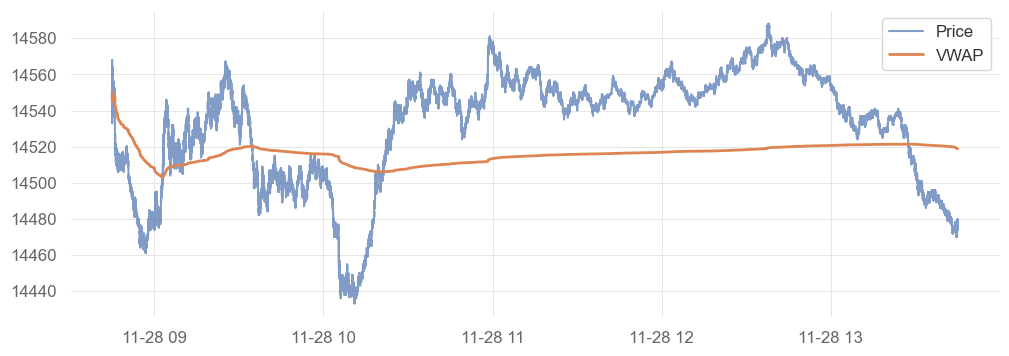

In [14]:
sample = df[df['session_id'] == df['session_id'].iloc[0]]

plt.figure(figsize=(12,4))
plt.plot(sample['Datetime'], sample['Price'], label='Price', alpha=0.7)
plt.plot(sample['Datetime'], sample['VWAP'], label='VWAP', linewidth=2)
plt.legend()
plt.show()


# Non-MR Day

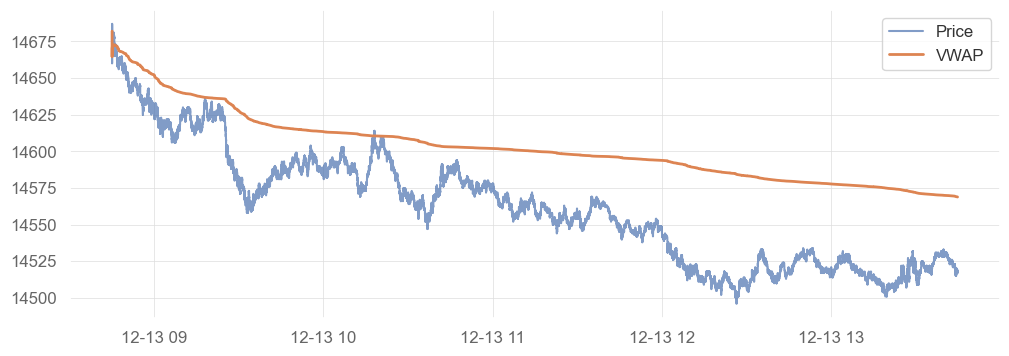

In [15]:
sample = df[df['session_id'] == df['session_id'].iloc[500000]]

plt.figure(figsize=(12,4))
plt.plot(sample['Datetime'], sample['Price'], label='Price', alpha=0.7)
plt.plot(sample['Datetime'], sample['VWAP'], label='VWAP', linewidth=2)
plt.legend()
plt.show()


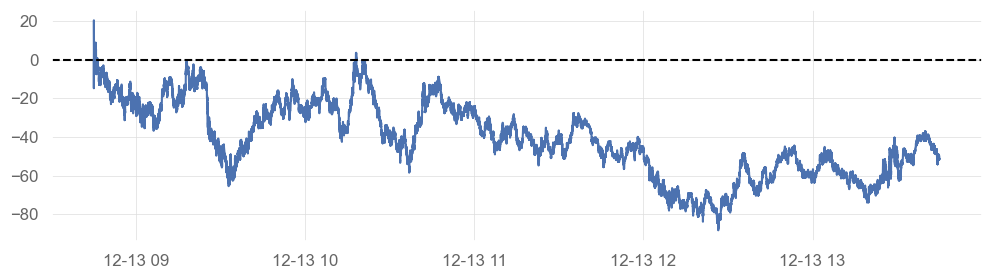

In [16]:
sample['dev'] = sample['Price'] - sample['VWAP']

plt.figure(figsize=(12,3))
plt.plot(sample['Datetime'], sample['dev'])
plt.axhline(0, color='black', linestyle='--')
plt.show()

In [17]:
df['dev'] = df['Price'] - df['VWAP']
df['dev'].describe()

count    2.406041e+07
mean    -2.214946e+00
std      7.477036e+01
min     -7.596760e+02
25%     -3.418910e+01
50%     -2.334652e-03
75%      3.260525e+01
max      5.239795e+02
Name: dev, dtype: float64

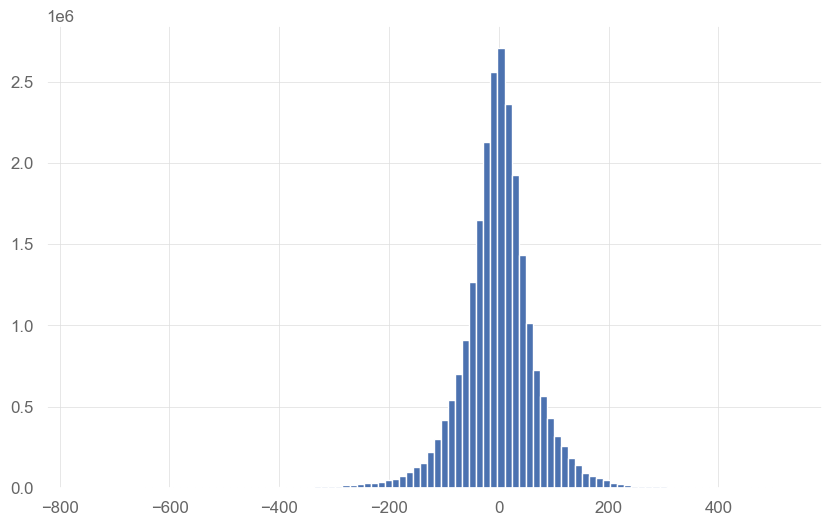

In [18]:
df['dev'].hist(bins=100)
plt.show()

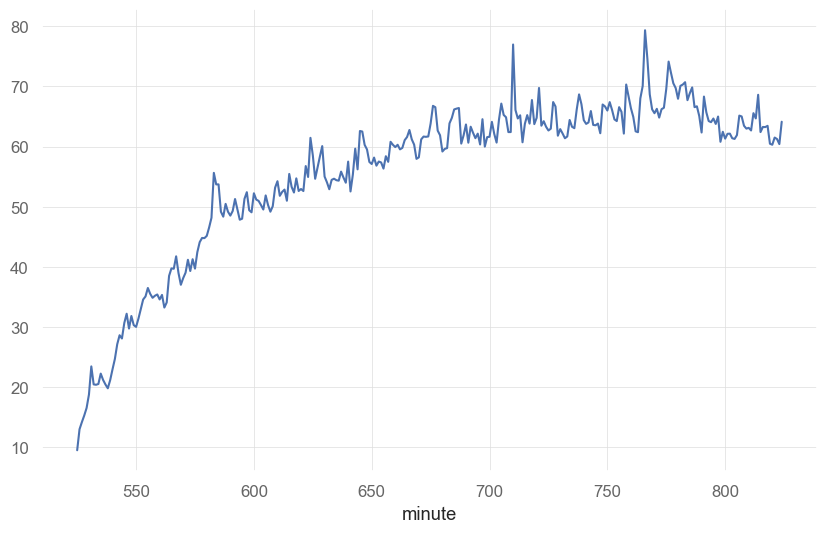

In [19]:
df['minute'] = df['Datetime'].dt.hour * 60 + df['Datetime'].dt.minute

abs_dev_by_time = df.groupby('minute')['dev'].apply(lambda x: x.abs().mean())
abs_dev_by_time.plot()
plt.show()

# Eyeball at aggregate level: no mean reverting 
# Next step: classify MR day and non-MR day

開盤前30分鐘 VWAP跟價格交叉幾次

In [20]:
open_mask = (
    (df['Datetime'].dt.time >= pd.to_datetime("08:45").time()) &
    (df['Datetime'].dt.time <= pd.to_datetime("09:15").time())
)

df_open = df[open_mask]

In [21]:
df_open['sign'] = np.sign(df_open['Price'] - df_open['VWAP'])

cross_count = (
    df_open
    .groupby('session_id')['sign']
    .apply(lambda x: (x.diff() != 0).sum())
)

用train data 六四法則來決定交叉幾次算MR day: 125次

In [22]:
train_days = (cross_count.index >= '2022-01-01') & \
             (cross_count.index <= '2024-06-30')

test_days  = (cross_count.index >= '2024-07-01')

threshold = cross_count.loc[train_days].quantile(0.4)

mr_flag = (cross_count >= threshold).astype(int)

df['is_mr_day'] = df['session_id'].map(mr_flag)

In [23]:
print(threshold)

125.0


In [24]:
# sanity check
pd.concat([
    mr_flag.loc[train_days].value_counts(normalize=True),
    mr_flag.loc[test_days].value_counts(normalize=True)
], axis=1, keys=['train', 'test'])

,train,test
sign,,
1,0.60105,0.617391
0,0.39895,0.382609


In [25]:
train_mask = df['session_id'] <= '2024-06-30'
test_mask  = df['session_id'] >= '2024-07-01'

df_train = df[train_mask].copy()
df_test  = df[test_mask].copy()

In [26]:
# save train and test
df_train.to_csv('df_train_week2.csv')
df_test.to_csv('df_test_week2.csv')

In [27]:
df_train = pd.read_csv('df_train_week2.csv', index_col=0)
df_train['Datetime'] = pd.to_datetime(df_train['Date'] + ' ' + df_train['Time'])
df_train.head()

,Symbol,Date,Time,Price,Volume,Datetime,session_id,PV,cum_PV,cum_V,VWAP,dev,minute,is_mr_day
0,TXF1,2022/11/28,08:45:00,14550.0,561,2022-11-28 08:45:00,2022-11-28,8162550.0,8162550.0,561,14550.000000,0.000000,525,1
1,TXF1,2022/11/28,08:45:00,14541.0,1,2022-11-28 08:45:00,2022-11-28,14541.0,8177091.0,562,14549.983986,-8.983986,525,1
2,TXF1,2022/11/28,08:45:00,14541.0,2,2022-11-28 08:45:00,2022-11-28,29082.0,8206173.0,564,14549.952128,-8.952128,525,1
3,TXF1,2022/11/28,08:45:00,14541.0,1,2022-11-28 08:45:00,2022-11-28,14541.0,8220714.0,565,14549.936283,-8.936283,525,1
4,TXF1,2022/11/28,08:45:00,14543.0,1,2022-11-28 08:45:00,2022-11-28,14543.0,8235257.0,566,14549.924028,-6.924028,525,1


## State-Based Discrete VWAP Mean Reversion Strategy

This strategy implements an intraday mean-reversion framework using Volume-Weighted Average Price (VWAP) as the reference level. Trading is conducted exclusively on pre-classified mean-reverting (MR) days.

At each tick, the deviation between the last traded price and the intraday VWAP is computed. Positions are determined using a state-based discrete mapping, where the target position depends solely on the current deviation level rather than the historical price path.

A dead zone is defined around VWAP to avoid trading on minor fluctuations. Once the deviation exceeds the threshold, positions are established in discrete units. As the deviation moves further away from VWAP, the strategy increases exposure stepwise, subject to a predefined maximum position limit. Long and short positions are symmetric.

The strategy begins trading 30 minutes after market open to avoid early-session volatility and does not rebalance outside the defined trading window. All positions are forcibly flattened at the end of each trading session to eliminate overnight risk.

By construction, the strategy is path-independent, avoids look-ahead bias, and is suitable for high-frequency intraday backtesting under realistic execution constraints.

# backtest: Daily version

In [28]:
import numpy as np
import pandas as pd

class StateBasedDiscreteVWAPMR:
    def __init__(
        self,
        entry_time="09:15",
        exit_time="13:25",
        threshold=20,
        step=10,
        max_pos=5
    ):
        self.entry_time = pd.to_datetime(entry_time).time()
        self.exit_time = pd.to_datetime(exit_time).time()

        self.threshold = threshold
        self.step = step
        self.max_pos = max_pos

        # state (reset daily)
        self.position = 0
        self.pnl = 0.0
        self.last_price = None

    def reset_day(self):
        self.position = 0
        self.pnl = 0.0
        self.last_price = None

    def _target_position(self, dev):
        """
        State-based discrete mapping:
        position = f(dev)
        """
        if abs(dev) <= self.threshold:
            return 0

        level = int((abs(dev) - self.threshold) // self.step) + 1
        level = min(level, self.max_pos)

        return -level if dev > 0 else level

    def on_tick(self, row):
        price = row["Price"]
        dev = row["dev"]
        t = row["Datetime"].time()

        # 1️⃣ Mark-to-market using OLD position
        if self.last_price is not None:
            self.pnl += self.position * (price - self.last_price)

        self.last_price = price

        # 2️⃣ Outside trading window → no rebalance
        if t < self.entry_time or t > self.exit_time:
            return

        # 3️⃣ Rebalance to state-based target position
        self.position = self._target_position(dev)

    def close_day(self, price):
        # Final MTM
        if self.last_price is not None:
            self.pnl += self.position * (price - self.last_price)

        self.position = 0


In [29]:
results = []

strategy = StateBasedDiscreteVWAPMR(
    entry_time="09:15",
    exit_time="13:25",
    threshold=20,
    step=10,
    max_pos=5
)

for day, day_df in df_train.groupby("session_id"):

    # MR day only
    if day_df["is_mr_day"].iloc[0] == 0:
        continue

    strategy.reset_day()

    for _, row in day_df.iterrows():
        strategy.on_tick(row)

    strategy.close_day(day_df["Price"].iloc[-1])

    results.append({
        "session_id": day,
        "pnl": strategy.pnl
    })

results_df = pd.DataFrame(results)


In [31]:
results_df["pnl"].describe()

count     229.000000
mean      539.978166
std       383.977469
min      -783.000000
25%       335.000000
50%       483.000000
75%       749.000000
max      2069.000000
Name: pnl, dtype: float64

In [32]:
stats = {
    "Total Days": len(results),
    "Win Rate (%)": round((pd.DataFrame(results)["pnl"] > 0).mean() * 100, 2),
    "Total PnL": pd.DataFrame(results)["pnl"].sum(),
    "Avg PnL / Day": pd.DataFrame(results)["pnl"].mean(),
    "Max Win / Day": pd.DataFrame(results)["pnl"].max(),
    "Max Loss / Day": pd.DataFrame(results)["pnl"].min(),
    "Profit Factor": (
        pd.DataFrame(results).loc[pd.DataFrame(results)["pnl"] > 0, "pnl"].sum() /
        abs(pd.DataFrame(results).loc[pd.DataFrame(results)["pnl"] < 0, "pnl"].sum())
        if (pd.DataFrame(results)["pnl"] < 0).any() else float("inf")
    )
}

pd.DataFrame(stats, index=["Value"]).T

,Value
Total Days,229.000000
Win Rate (%),94.320000
Total PnL,123655.000000
Avg PnL / Day,539.978166
Max Win / Day,2069.000000
Max Loss / Day,-783.000000
Profit Factor,42.453235


## Backtest: Trade version

In [33]:
import numpy as np
import pandas as pd

class StateBasedDiscreteVWAPMR:
    def __init__(
        self,
        entry_time="09:15",
        exit_time="13:25",
        threshold=20,
        step=10,
        max_pos=5
    ):
        self.entry_time = pd.to_datetime(entry_time).time()
        self.exit_time = pd.to_datetime(exit_time).time()

        self.threshold = threshold
        self.step = step
        self.max_pos = max_pos

        self.in_trade = False
        self.trade_pnl = 0.0
        self.trade_side = None
        self.trades = []

        # state (reset daily)
        self.position = 0
        self.pnl = 0.0
        self.last_price = None

    def reset_day(self):
        self.position = 0
        self.pnl = 0.0
        self.last_price = None

        self.in_trade = False
        self.trade_pnl = 0.0
        self.trade_side = None
    def _target_position(self, dev):
        """
        State-based discrete mapping:
        position = f(dev)
        """
        if abs(dev) <= self.threshold:
            return 0

        level = int((abs(dev) - self.threshold) // self.step) + 1
        level = min(level, self.max_pos)

        return -level if dev > 0 else level
    
    def on_tick(self, row):
        price = row["Price"]
        dev = row["dev"]
        t = row["Datetime"].time()

        # 1️⃣ MTM
        if self.last_price is not None:
            delta = self.position * (price - self.last_price)
            self.pnl += delta
            if self.in_trade:
                self.trade_pnl += delta

        self.last_price = price

        if t < self.entry_time or t > self.exit_time:
            return

        target_pos = self._target_position(dev)

        # 2️⃣ trade entry
        if not self.in_trade and self.position == 0 and target_pos != 0:
            self.in_trade = True
            self.trade_pnl = 0.0
            self.trade_side = "long" if target_pos > 0 else "short"

        # 3️⃣ trade exit
        if self.in_trade and self.position != 0 and target_pos == 0:
            self.trades.append({
                "side": self.trade_side,
                "pnl": self.trade_pnl
            })
            self.in_trade = False
            self.trade_pnl = 0.0
            self.trade_side = None

        self.position = target_pos

    def close_day(self, price):
        if self.last_price is not None:
            delta = self.position * (price - self.last_price)
            self.pnl += delta
            if self.in_trade:
                self.trade_pnl += delta

        # EOD 強制出場
        if self.in_trade:
            self.trades.append({
                "side": self.trade_side,
                "pnl": self.trade_pnl
            })

        self.position = 0


In [34]:
all_trades = []

strategy = StateBasedDiscreteVWAPMR(
    entry_time="09:15",
    exit_time="13:25",
    threshold=20,
    step=10,
    max_pos=5
)

for day, day_df in df_train.groupby("session_id"):

    # 只在 MR day 交易
    if day_df["is_mr_day"].iloc[0] == 0:
        continue

    strategy.reset_day()

    for _, row in day_df.iterrows():
        strategy.on_tick(row)

    # EOD 強制平倉
    strategy.close_day(day_df["Price"].iloc[-1])

    # 收集當天完成的 trades
    if len(strategy.trades) > 0:
        for tr in strategy.trades:
            tr["session_id"] = day
            all_trades.append(tr)

    # 清空 strategy 內的 trade buffer（很重要）
    strategy.trades = []

# Stats before cost

In [35]:
trades_df = pd.DataFrame(all_trades)

stats = {
    "Total Trades": len(trades_df),
    "Win Rate (%)": round((trades_df["pnl"] > 0).mean() * 100, 2),
    "Total PnL": trades_df["pnl"].sum(),
    "Avg PnL / Trade": trades_df["pnl"].mean(),
    "Max Win": trades_df["pnl"].max(),
    "Max Loss": trades_df["pnl"].min(),
    "Profit Factor": (
        trades_df.loc[trades_df["pnl"] > 0, "pnl"].sum() /
        abs(trades_df.loc[trades_df["pnl"] < 0, "pnl"].sum())
        if (trades_df["pnl"] < 0).any() else float("inf")
    )
}

pd.DataFrame(stats, index=["Value"]).T

,Value
Total Trades,31224.000000
Win Rate (%),98.710000
Total PnL,123655.000000
Avg PnL / Trade,3.960255
Max Win,671.000000
Max Loss,-855.000000
Profit Factor,11.163982


# stats after cost: 1 tick cost for every position change

In [36]:

class StateBasedDiscreteVWAPMR:
    def __init__(
        self,
        entry_time="09:15",
        exit_time="13:25",
        threshold=20,
        step=10,
        max_pos=5,
        cost_per_contract=1.0  # ✅ 新增：每口成本（ticks）
    ):
        self.entry_time = pd.to_datetime(entry_time).time()
        self.exit_time = pd.to_datetime(exit_time).time()

        self.threshold = threshold
        self.step = step
        self.max_pos = max_pos
        self.cost_per_contract = cost_per_contract

        self.reset_day()
        self.trades = []

    def reset_day(self):
        self.position = 0
        self.last_price = None

        self.in_trade = False
        self.trade_pnl = 0.0
        self.trade_side = None
        self.entry_dev = None

    def _target_position(self, dev):
        if abs(dev) <= self.threshold:
            return 0

        level = int((abs(dev) - self.threshold) // self.step) + 1
        level = min(level, self.max_pos)

        return -level if dev > 0 else level

    def on_tick(self, row):
        price = row["Price"]
        dev = row["dev"]
        t = row["Datetime"].time()

        # ---------- 1️⃣ MTM PnL（未實現） ----------
        if self.last_price is not None:
            delta = self.position * (price - self.last_price)
            if self.in_trade:
                self.trade_pnl += delta

        self.last_price = price

        # ---------- 2️⃣ trading window ----------
        if t < self.entry_time or t > self.exit_time:
            return

        target_pos = self._target_position(dev)
        old_pos = self.position

        # ---------- 3️⃣ trade entry ----------
        if not self.in_trade and old_pos == 0 and target_pos != 0:
            self.in_trade = True
            self.trade_pnl = 0.0
            self.trade_side = "long" if target_pos > 0 else "short"
            self.entry_dev = abs(dev)

        # ---------- 4️⃣ position change + cost ----------
        if target_pos != old_pos:
            traded_size = abs(target_pos - old_pos)
            cost = traded_size * self.cost_per_contract
            if self.in_trade:
                self.trade_pnl -= cost

        self.position = target_pos

        # ---------- 5️⃣ trade exit ----------
        if self.in_trade and old_pos != 0 and target_pos == 0:
            self.trades.append({
                "side": self.trade_side,
                "pnl": self.trade_pnl,
                "entry_dev": self.entry_dev   # ✅ 新增
            })
            self.in_trade = False
            self.trade_pnl = 0.0
            self.trade_side = None

    def close_day(self, price):
        # EOD MTM
        if self.last_price is not None:
            delta = self.position * (price - self.last_price)
            if self.in_trade:
                self.trade_pnl += delta

        # EOD flatten cost
        if self.position != 0:
            cost = abs(self.position) * self.cost_per_contract
            if self.in_trade:
                self.trade_pnl -= cost

        if self.in_trade:
            self.trades.append({
                "side": self.trade_side,
                "pnl": self.trade_pnl
            })

        self.position = 0
        self.in_trade = False


In [37]:
all_trades = []

strategy = StateBasedDiscreteVWAPMR(
    entry_time="09:15",
    exit_time="13:25",
    threshold=20,
    step=10,
    max_pos=5
)

for day, day_df in df_train.groupby("session_id"):

    # 只在 MR day 交易
    if day_df["is_mr_day"].iloc[0] == 0:
        continue

    strategy.reset_day()

    for _, row in day_df.iterrows():
        strategy.on_tick(row)

    # EOD 強制平倉
    strategy.close_day(day_df["Price"].iloc[-1])

    # 收集當天完成的 trades
    if len(strategy.trades) > 0:
        for tr in strategy.trades:
            tr["session_id"] = day
            all_trades.append(tr)

    # 清空 strategy 內的 trade buffer（很重要）
    strategy.trades = []

In [38]:

trades_df = pd.DataFrame(all_trades)

stats = {
    "Total Trades": len(trades_df),
    "Win Rate (%)": round((trades_df["pnl"] > 0).mean() * 100, 2),
    "Total PnL": trades_df["pnl"].sum(),
    "Avg PnL / Trade": trades_df["pnl"].mean(),
    "Max Win": trades_df["pnl"].max(),
    "Max Loss": trades_df["pnl"].min(),
    "Profit Factor": (
        trades_df.loc[trades_df["pnl"] > 0, "pnl"].sum() /
        abs(trades_df.loc[trades_df["pnl"] < 0, "pnl"].sum())
        if (trades_df["pnl"] < 0).any() else float("inf")
    )
}

pd.DataFrame(stats, index=["Value"]).T

,Value
Total Trades,31224.000000
Win Rate (%),7.210000
Total PnL,-105417.000000
Avg PnL / Trade,-3.376153
Max Win,61.000000
Max Loss,-1271.000000
Profit Factor,0.038482


In [39]:
trades_df["entry_dev_bin"] = pd.cut(
    trades_df["entry_dev"],
    bins=[0, 20, 40, 60, 80, 120, 999]
)

In [40]:
trades_df.groupby("entry_dev_bin")["pnl"].mean()

entry_dev_bin
(20, 40]      -2.059151
(40, 60]     -75.687500
(60, 80]     -21.500000
(80, 120]   -869.000000
Name: pnl, dtype: float64